In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

RAW_FILE="suvidha_loan_predictions_raw.csv"
df=pd.read_csv(RAW_FILE)

def money_clean(x):
    if pd.isna(x): return np.nan
    return float(str(x).replace(",","").replace("Rs ","").replace("₹","").strip())

def flag_bool(x):
    s=str(x).strip().lower()
    if s in {"yes","y","1","true"}: return True
    if s in {"no","n","0","false"}: return False
    return np.nan

# Q1
print("Shape:",df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())


Shape: (2400, 9)

Dtypes:
loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing values:
loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


In [2]:
# Q2
df["loan_amount"]=df["loan_amount"].map(money_clean)
print(df["loan_amount"].dtype)
print(df["loan_amount"].head())
print("Interpretation: currency text and commas are removed and loan_amount is numeric.")

float64
0     60777.81992
1    258399.89230
2    114338.03220
3     60919.14875
4    104225.15810
Name: loan_amount, dtype: float64
Interpretation: currency text and commas are removed and loan_amount is numeric.


In [3]:
# Q3
raw_actual=sorted(df["actual_default"].dropna().astype(str).str.strip().unique().tolist())
raw_flag=sorted(df["model_flag"].dropna().astype(str).str.strip().unique().tolist())
print("Raw actual_default values mapped:",raw_actual)
print("Raw model_flag values mapped:",raw_flag)
df["actual_default"]=df["actual_default"].map(flag_bool)
df["model_flag"]=df["model_flag"].map(flag_bool)
print("\nMapped values:")
print("actual_default:",df["actual_default"].value_counts(dropna=False).to_dict())
print("model_flag:",df["model_flag"].value_counts(dropna=False).to_dict())
print("Interpretation: Yes/Y/1/true map to True and No/N/0/false map to False; blanks remain missing.")

Raw actual_default values mapped: ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes']
Raw model_flag values mapped: ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes']

Mapped values:
actual_default: {False: 2161, True: 199, nan: 40}
model_flag: {False: 2222, True: 156, nan: 22}
Interpretation: Yes/Y/1/true map to True and No/N/0/false map to False; blanks remain missing.


In [4]:
# Q4
before=len(df)
drop_mask=df["actual_default"].isna() | df["model_flag"].isna()
dropped=df.loc[drop_mask].copy()
df_eval=df.loc[~drop_mask].copy()
df_eval.to_csv("suvidha_loan_predictions_cleaned.csv", index=False)
print("Saved: suvidha_loan_predictions_cleaned.csv")
print("Rows dropped:",len(dropped))
print("Rows retained:",len(df_eval))
print("Actual-default blanks:",df["actual_default"].isna().sum())
print("Model-flag blanks:",df["model_flag"].isna().sum())
print("Interpretation: these rows are excluded because the outcome or prediction is unknown; imputing either would invent classification evidence and distort the confusion matrix.")

Saved: suvidha_loan_predictions_cleaned.csv
Rows dropped: 61
Rows retained: 2339
Actual-default blanks: 40
Model-flag blanks: 22
Interpretation: these rows are excluded because the outcome or prediction is unknown; imputing either would invent classification evidence and distort the confusion matrix.


In [5]:
# Q5
df["monthly_income_clean"]=pd.to_numeric(
    df["monthly_income"].replace({"not disclosed":np.nan,"-1":np.nan}),
    errors="coerce"
)
print("Missing/invalid monthly_income after cleaning:",df["monthly_income_clean"].isna().sum())
print("Interpretation: -1 is an invalid placeholder rather than a real income, while 'not disclosed' is explicitly non-disclosure; both are therefore treated as missing for numeric analysis, but the distinction is documented rather than silently conflated.")

Missing/invalid monthly_income after cleaning: 96
Interpretation: -1 is an invalid placeholder rather than a real income, while 'not disclosed' is explicitly non-disclosure; both are therefore treated as missing for numeric analysis, but the distinction is documented rather than silently conflated.


In [6]:
# Q6
y=df_eval["actual_default"].astype(int)
pred=df_eval["model_flag"].astype(int)
cm=confusion_matrix(y,pred)
tn,fp,fn,tp=cm.ravel()
cm_table=pd.DataFrame(cm,index=["Actual No Default","Actual Default"],columns=["Predicted No Default","Predicted Default"])
display(cm_table)
print(f"TN={tn}: correctly left a non-defaulting borrower unflagged.")
print(f"FP={fp}: a non-defaulting borrower was incorrectly flagged, creating a wasted call.")
print(f"FN={fn}: a borrower who defaulted was missed by the model.")
print(f"TP={tp}: a borrower who defaulted was correctly flagged.")
print("Interpretation: the matrix separates costly missed defaults from cheaper false alarms.")

,Predicted No Default,Predicted Default
Actual No Default,2122,20
Actual Default,64,133


TN=2122: correctly left a non-defaulting borrower unflagged.
FP=20: a non-defaulting borrower was incorrectly flagged, creating a wasted call.
FN=64: a borrower who defaulted was missed by the model.
TP=133: a borrower who defaulted was correctly flagged.
Interpretation: the matrix separates costly missed defaults from cheaper false alarms.


In [7]:
# Q7
acc=accuracy_score(y,pred)
print(f"Accuracy = {acc:.4f} ({acc:.2%})")
print("Interpretation: accuracy is misleading here because only about 9% of loans default. A trivial all-no-default model would already be near 91% accurate, so a high accuracy value can hide poor default detection.")

Accuracy = 0.9641 (96.41%)
Interpretation: accuracy is misleading here because only about 9% of loans default. A trivial all-no-default model would already be near 91% accurate, so a high accuracy value can hide poor default detection.


In [8]:
# Q8
prec=precision_score(y,pred); print(f"Precision = {prec:.4f} ({prec:.2%})")
print(f"Interpretation: about {prec:.1%} of the loans flagged as defaults were actually defaults, so roughly {1-prec:.1%} of flagged calls were false alarms.")

Precision = 0.8693 (86.93%)
Interpretation: about 86.9% of the loans flagged as defaults were actually defaults, so roughly 13.1% of flagged calls were false alarms.


In [9]:
# Q9
rec=recall_score(y,pred); print(f"Recall = {rec:.4f} ({rec:.2%})")
print(f"Interpretation: the model catches about {rec:.1%} of observed defaults and misses {1-rec:.1%}.")

Recall = 0.6751 (67.51%)
Interpretation: the model catches about 67.5% of observed defaults and misses 32.5%.


In [10]:
# Q10
specificity=tn/(tn+fp)
print(f"Specificity = {specificity:.4f} ({specificity:.2%})")
print(f"False-positive rate = {1-specificity:.2%}")
print("Interpretation: high specificity means most non-defaulting borrowers are correctly left alone; the remaining false alarms consume collections-officer time.")

Specificity = 0.9907 (99.07%)
False-positive rate = 0.93%
Interpretation: high specificity means most non-defaulting borrowers are correctly left alone; the remaining false alarms consume collections-officer time.


In [11]:
# Q11
f1=f1_score(y,pred)
print(f"F1 = {f1:.4f}")
print("Interpretation: F1 balances precision and recall, but it is not necessarily the business-optimal single objective here because the assignment states that a missed default costs much more than a wasted call. Recall therefore deserves extra weight when selecting a threshold.")

F1 = 0.7600
Interpretation: F1 balances precision and recall, but it is not necessarily the business-optimal single objective here because the assignment states that a missed default costs much more than a wasted call. Recall therefore deserves extra weight when selecting a threshold.


In [12]:
# Q12
print(f"Observed FN={fn}; observed FP={fp}.")
print("Given the stated cost asymmetry, higher recall is preferable even if it increases false alarms, because each FN represents a missed default while an FP represents an extra collection call.")


Observed FN=64; observed FP=20.
Given the stated cost asymmetry, higher recall is preferable even if it increases false alarms, because each FN represents a missed default while an FP represents an extra collection call.


In [13]:
# Q13
threshold=.3
thr_pred=(df_eval["risk_score"]>=threshold).astype(int)
cm30=confusion_matrix(y,thr_pred)
tn30,fp30,fn30,tp30=cm30.ravel()
p30=precision_score(y,thr_pred); r30=recall_score(y,thr_pred)
print("Using the same evaluable rows as the hard-flag evaluation:")
display(pd.DataFrame(cm30,index=["Actual No Default","Actual Default"],columns=["Predicted No Default","Predicted Default"]))
print(f"Precision={p30:.4f}, Recall={r30:.4f}")
print("Interpretation: lowering the cutoff to 0.3 drives recall to 100% but creates many false alarms and reduces precision sharply; it supports recall but imposes a substantial operational burden.")

Using the same evaluable rows as the hard-flag evaluation:


,Predicted No Default,Predicted Default
Actual No Default,664,1478
Actual Default,0,197


Precision=0.1176, Recall=1.0000
Interpretation: lowering the cutoff to 0.3 drives recall to 100% but creates many false alarms and reduces precision sharply; it supports recall but imposes a substantial operational burden.


,Threshold,Precision,Recall
0,0.1,0.085,1.000
1,0.2,0.092,1.000
2,0.3,0.118,1.000
3,0.4,0.203,0.970
4,0.5,0.441,0.929
5,0.6,0.826,0.701
6,0.7,0.974,0.386
7,0.8,1.000,0.132
8,0.9,1.000,0.015


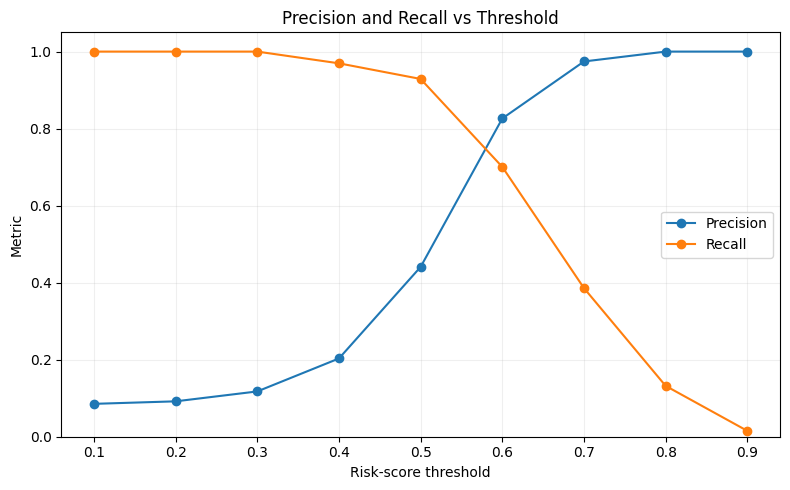

Fine-grid crossover ≈ 0.582, where precision≈recall≈0.763.
Interpretation: the crossover is around 0.58; moving upward from there trades recall for fewer false alarms, while moving downward trades precision for more default capture.


In [14]:
# Q14
thresholds=np.arange(.1,1.0,.1)
curve=[]
for t in thresholds:
    pp=(df_eval["risk_score"]>=round(float(t),1)).astype(int)
    curve.append([t,precision_score(y,pp,zero_division=0),recall_score(y,pp,zero_division=0)])
curve_df=pd.DataFrame(curve,columns=["Threshold","Precision","Recall"])
display(curve_df.round(3))
plt.figure(figsize=(8,5))
plt.plot(curve_df["Threshold"],curve_df["Precision"],marker="o",label="Precision")
plt.plot(curve_df["Threshold"],curve_df["Recall"],marker="o",label="Recall")
plt.xlabel("Risk-score threshold"); plt.ylabel("Metric"); plt.title("Precision and Recall vs Threshold")
plt.xticks(thresholds); plt.ylim(0,1.05); plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.show()
# Fine-grained crossover for interpretation
fine=[]
for t in np.linspace(.1,.9,801):
    pp=(df_eval["risk_score"]>=t).astype(int)
    p=precision_score(y,pp,zero_division=0); r=recall_score(y,pp,zero_division=0)
    fine.append((abs(p-r),t,p,r))
_,cross_t,cross_p,cross_r=min(fine,key=lambda z:z[0])
print(f"Fine-grid crossover ≈ {cross_t:.3f}, where precision≈recall≈{cross_p:.3f}.")
print("Interpretation: the crossover is around 0.58; moving upward from there trades recall for fewer false alarms, while moving downward trades precision for more default capture.")

In [15]:
# Q15
print("H0: The mean loan_amount is the same for loans that defaulted and loans that did not default.")
print("H1: The mean loan_amount differs between loans that defaulted and loans that did not default.")
print("Interpretation: this is a two-sided comparison of the two group means.")

H0: The mean loan_amount is the same for loans that defaulted and loans that did not default.
H1: The mean loan_amount differs between loans that defaulted and loans that did not default.
Interpretation: this is a two-sided comparison of the two group means.


In [16]:
# Q16
default_amount=df_eval.loc[df_eval["actual_default"],"loan_amount"]
nondefault_amount=df_eval.loc[df_eval["actual_default"].eq(False),"loan_amount"]
print(f"Defaulted mean loan_amount = {default_amount.mean():.2f}")
print(f"Non-defaulted mean loan_amount = {nondefault_amount.mean():.2f}")
print(f"Observed difference = {default_amount.mean()-nondefault_amount.mean():.2f}")
print("Interpretation: the defaulted group has a higher sample mean, but the observed difference must be tested before treating it as evidence of a population difference.")

Defaulted mean loan_amount = 96899.91
Non-defaulted mean loan_amount = 92408.81
Observed difference = 4491.10
Interpretation: the defaulted group has a higher sample mean, but the observed difference must be tested before treating it as evidence of a population difference.


In [17]:
# Q17
loan_test=ttest_ind(default_amount,nondefault_amount,equal_var=False,nan_policy="omit")
print("Test: Welch two-sample t-test (unequal variances).")
print(f"t-statistic = {loan_test.statistic:.4f}")
print(f"p-value = {loan_test.pvalue:.6f}")
print("Interpretation: Welch's test is appropriate for comparing two independent groups without assuming equal population variances.")

Test: Welch two-sample t-test (unequal variances).
t-statistic = 1.3588
p-value = 0.175574
Interpretation: Welch's test is appropriate for comparing two independent groups without assuming equal population variances.


In [18]:
# Q18
alpha=.05
print(f"p-value={loan_test.pvalue:.6f}; alpha={alpha}")
print("Decision: fail to reject H0." if loan_test.pvalue>=alpha else "Decision: reject H0.")
print("Branch-manager conclusion: the pilot data do not provide statistically significant evidence at the 5% level that average loan amount differs between defaulted and non-defaulted loans.")

p-value=0.175574; alpha=0.05
Decision: fail to reject H0.
Branch-manager conclusion: the pilot data do not provide statistically significant evidence at the 5% level that average loan amount differs between defaulted and non-defaulted loans.


In [19]:
# Q19
print("Type I error: concluding that defaulted and non-defaulted borrowers have different average loan amounts when no population difference exists. Type II error: failing to detect a real difference in average loan amount. For this lending-policy question, a Type I error could lead the branch to introduce an unnecessary loan-size policy; a Type II error could cause the branch to overlook a genuinely useful risk signal. Which is operationally riskier depends on the cost of those two policy mistakes; the classification problem's stated FN-versus-FP cost does not automatically transfer to this separate mean-comparison test.")

Type I error: concluding that defaulted and non-defaulted borrowers have different average loan amounts when no population difference exists. Type II error: failing to detect a real difference in average loan amount. For this lending-policy question, a Type I error could lead the branch to introduce an unnecessary loan-size policy; a Type II error could cause the branch to overlook a genuinely useful risk signal. Which is operationally riskier depends on the cost of those two policy mistakes; the classification problem's stated FN-versus-FP cost does not automatically transfer to this separate mean-comparison test.


In [20]:
# Q20
default_rate=df_eval.loc[df_eval["actual_default"],"interest_rate"]
nondefault_rate=df_eval.loc[df_eval["actual_default"].eq(False),"interest_rate"]
rate_test=ttest_ind(default_rate,nondefault_rate,equal_var=False,nan_policy="omit")
print(f"Defaulted mean interest_rate = {default_rate.mean():.3f}")
print(f"Non-defaulted mean interest_rate = {nondefault_rate.mean():.3f}")
print(f"t-statistic = {rate_test.statistic:.4f}")
print(f"p-value = {rate_test.pvalue:.6f}")
print("Decision:", "fail to reject H0" if rate_test.pvalue>=.05 else "reject H0")
print("Interpretation: the conclusion does not change; the pilot does not show a statistically significant difference in mean interest rate at alpha=0.05.")

Defaulted mean interest_rate = 14.802
Non-defaulted mean interest_rate = 14.462
t-statistic = 1.5778
p-value = 0.115960
Decision: fail to reject H0
Interpretation: the conclusion does not change; the pilot does not show a statistically significant difference in mean interest rate at alpha=0.05.


In [21]:
# Q21
summary=pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1"],
    "Value":[accuracy_score(y,pred),precision_score(y,pred),recall_score(y,pred),f1_score(y,pred)]
})
display(summary.style.format({"Value":"{:.3f}"}))
print("Interpretation: the hard model flag has high accuracy and specificity, but recall is materially lower than 100%, so some defaults are missed.")

,Metric,Value
0,Accuracy,0.964
1,Precision,0.869
2,Recall,0.675
3,F1,0.760


Interpretation: the hard model flag has high accuracy and specificity, but recall is materially lower than 100%, so some defaults are missed.


In [22]:
# Q22
print("Recommended starting threshold: 0.50.")
print("At threshold 0.50, precision is about 43.9% and recall about 93.0% on the evaluable ground-truth rows. Because the business explicitly says missed defaults cost much more than wasted calls, this threshold retains substantially more default capture than 0.60 while avoiding the extreme false-alarm rate seen at 0.30. It should be treated as a pilot starting point and monitored operationally rather than as a permanent cutoff.")

Recommended starting threshold: 0.50.
At threshold 0.50, precision is about 43.9% and recall about 93.0% on the evaluable ground-truth rows. Because the business explicitly says missed defaults cost much more than wasted calls, this threshold retains substantially more default capture than 0.60 while avoiding the extreme false-alarm rate seen at 0.30. It should be treated as a pilot starting point and monitored operationally rather than as a permanent cutoff.


In [23]:
# Q23
print("Non-statistical risk: officer fatigue. If the threshold is lowered too far, the number of false alarms can become large enough that collections staff start ignoring or batching alerts, reducing the practical value of the early-warning system even if recall improves on paper.")


Non-statistical risk: officer fatigue. If the threshold is lowered too far, the number of false alarms can become large enough that collections staff start ignoring or batching alerts, reducing the practical value of the early-warning system even if recall improves on paper.


In [24]:
# Q24
print("Rollout recommendation: proceed only as a controlled, monitored rollout rather than an unrestricted all-branch deployment. The current hard flag has 86.9% precision, 67.5% recall, 76.0% F1, and 96.4% accuracy, with 64 observed false negatives versus 20 false positives. The threshold analysis shows that lowering the cutoff can substantially increase recall, but at the cost of many more false alarms. A 0.50 threshold is a reasonable starting point under the stated cost asymmetry, provided officer workload and downstream outcomes are monitored. The two mean-comparison tests do not provide statistically significant evidence of differences in loan amount or interest rate between default groups at alpha=0.05, so those variables alone should not drive a lending-policy change.")


Rollout recommendation: proceed only as a controlled, monitored rollout rather than an unrestricted all-branch deployment. The current hard flag has 86.9% precision, 67.5% recall, 76.0% F1, and 96.4% accuracy, with 64 observed false negatives versus 20 false positives. The threshold analysis shows that lowering the cutoff can substantially increase recall, but at the cost of many more false alarms. A 0.50 threshold is a reasonable starting point under the stated cost asymmetry, provided officer workload and downstream outcomes are monitored. The two mean-comparison tests do not provide statistically significant evidence of differences in loan amount or interest rate between default groups at alpha=0.05, so those variables alone should not drive a lending-policy change.


In [25]:
# Q25
print("For the second pilot, the most useful addition would be a longer observation window so every scored loan has enough time to reach the 90-day outcome and fewer labels are missing. A larger default sample would also improve precision/recall estimates, while additional features could be evaluated separately. The priority is to collect more complete outcome labels and enough default events to make threshold comparisons less sensitive to sampling noise.")


For the second pilot, the most useful addition would be a longer observation window so every scored loan has enough time to reach the 90-day outcome and fewer labels are missing. A larger default sample would also improve precision/recall estimates, while additional features could be evaluated separately. The priority is to collect more complete outcome labels and enough default events to make threshold comparisons less sensitive to sampling noise.
